In [1]:
from simple_neural_mpc.controllers import MPC
from simple_neural_mpc.robots import Unicycle
from simple_neural_mpc.simulation.trajectory_tracking import (
    TrajectoryTrackingSimulation,
)
from simple_neural_mpc.utils import project_root

In [2]:
import numpy as np
from simple_neural_mpc.neural_modeling.learner.derivative_learner import (
    DerivativeLearner,
)
from simple_neural_mpc.neural_modeling.learner.next_state_learner import (
    NextStateLearner,
)
import torch
from simple_neural_mpc.robots.unicycle import UnicycleState
from simple_neural_mpc.config.mpc_config import MPCConfig

seed = 134
torch.random.manual_seed(seed)
np.random.seed(seed)

if MPCConfig.predicts_state == True:
    print("USING STATE LEARNER")
    model = NextStateLearner(3, 2, in_mpc=True)
else:
    print("USING DERIVATIVE LEARNER")
    model = DerivativeLearner(3, 2, in_mpc=True)
    
    
model_name = "derivative"
if MPCConfig.predicts_state == True:
    model_name = "state_pinn" if MPCConfig.is_pinn else "state"

model.load_state_dict(
    torch.load(
        f"{project_root()}/simple_neural_mpc/neural_modeling/models/{model_name}.pth",
        weights_only=False,
        map_location=torch.device("cpu"),
    ),
)
model.eval()

robot = Unicycle(model)
controller = MPC(robot, to_generate=True)

USING DERIVATIVE LEARNER


make: *** No rule to make target 'clean_all'.  Stop.


cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o acados_solver_unicycle.o acados_solver_unicycle.c
cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o unicycle_model/unicycle_expl_ode_fun.o unicycle_model/unicycle_expl_ode_fun.c
cc -fPIC -std=c99   -O2 -I/home/neverorfrog/code/mpc-libs/acados/include -I/home/neverorfrog/code/mpc-libs/acados/include/acados -I/home/neverorfrog/code/mpc-libs/acados/include/blasfeo/include -I/home/neverorfrog/code/mpc-libs/acados/include/hpipm/include  -c -o unicycle_model/unicycle_expl_vde_forw.o unicycle_model/unicycle_expl_vde_forw.c


In file included from /home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/ndarraytypes.h:1913,
                 from /home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/ndarrayobject.h:12,
                 from /home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/arrayobject.h:5,
                 from acados_ocp_solver_pyx.c:1230:
/home/neverorfrog/miniconda3/envs/l4casadi/lib/python3.11/site-packages/numpy/_core/include/numpy/npy_1_7_deprecated_api.h:17:2: warning: #warning "Using deprecated NumPy API, disable it with " "#define NPY_NO_DEPRECATED_API NPY_1_7_API_VERSION" [-Wcpp]
   17 | #warning "Using deprecated NumPy API, disable it with " \
      |  ^~~~~~~


cc  -shared \
-o acados_ocp_solver_pyx.so \
-Wl,-rpath=/home/neverorfrog/code/mpc-libs/acados/lib \
acados_ocp_solver_pyx.o \
/home/neverorfrog/code/simple_neural_mpc/simple_neural_mpc/scripts/acados_generated_files/c_generated_code/libacados_ocp_solver_unicycle.so \
-L/home/neverorfrog/code/mpc-libs/acados/lib -lacados -lhpipm -lblasfeo -lm


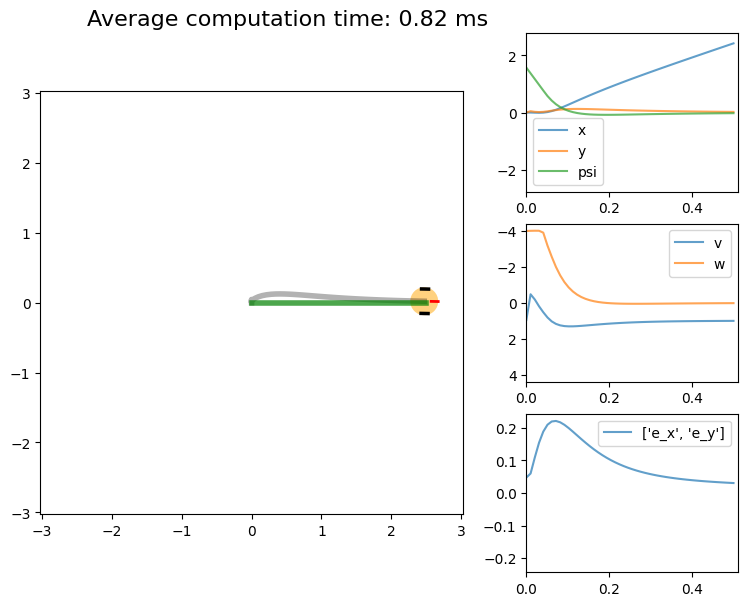

In [3]:
from simple_neural_mpc.simulation.trajectory import Dritto, Zero, Circle

# reference = Circle(freq = 0.1, radius = 1)
# reference = Zero()
reference = Dritto()
simulation = TrajectoryTrackingSimulation("mpc", robot, controller, reference)
simulation.t = 0
robot.state = UnicycleState(0, 0, np.pi / 2)
simulation.run(N=50, animate=False, save=False)